# e5 — Headline Regressions

Dependent variable: **Economic Complexity Index** (ECI), level.

Estimation strategy:

| # | Spec | FE | Standard Errors | Sample |
|---|---|---|---|---|
| 1 | Headline | Country + Year | Country-clustered | Imputed (pooled across M=10) |
| 2 | Robust SE | Country + Year | Two-way clustered (CGM) | Imputed (pooled across M=10) |
| 3 | Parsimonious + interactions | Country + Year | Country-clustered | Imputed (pooled across M=10) |
| 4 | v2 comparison | None | Country-clustered | Imputed (pooled across M=10) |
| 5 | Robustness | Country + Year | Country-clustered | Observed-only |

Within-country, within-year identification (Models 1-3, 5) addresses the
canonical resource-curse critique that cross-sectional correlations conflate
geography, history, and institutions with resource exposure. Year FE absorbs
the COVID shock as a common time effect; the COVID interactions
(`post_2019 × *_share`) then identify the differential resource impact.

Standard errors pooled across M=10 imputations via Rubin's rules (within-variance
+ between-variance correction). Fraction of Missing Information (FMI) reported
for each coefficient.

Notes:
- Forestry-rents interactions from v2 are dropped (no Master_v2 equivalent).
- The "Total_Production_Value" variable is queued for re-introduction once
  the e0 PRODVAL_PATH collision is fixed (see todo).


## 1. Setup

In [1]:
import os, sys, time, warnings, itertools
from pathlib import Path
import numpy as np
import pandas as pd
from types import SimpleNamespace

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sys.path.insert(0, '.')
import _config as cfg
from _mice_pool import pool_scalars, iter_imputations, load_imputations, PooledScalar

import statsmodels.api as sm
from linearmodels.panel import PanelOLS

EXT  = Path('.').resolve()
INTER = EXT / 'intermediary'

print(f'Working dir: {EXT}')
print(f'Year range:  {cfg.YEAR_MIN}-{cfg.YEAR_MAX}')


Working dir: /Users/leoss/Desktop/GitHub/leoss14.github.io/projects/capstone/New code/extension_2024
Year range:  1995-2023


## 2. Variable definitions and transforms

In [2]:
# Common transforms applied identically to each of the M panels and to the
# observed-only panel. Mean-centering uses the grand sample mean within each
# panel (so the interaction coefficients are interpretable at the mean of the
# interacted variable).

# Variables we expect to find in Master_v2 (verified at load time).
# If something is missing, the cell prints a warning and drops it from the spec.
LOG_VARS = [
    ('Human capital index', 'log_HCI'),
    ('Gross fixed capital formation, all, Constant prices, Percent of GDP', 'log_GFCF'),
    ('GDP per capita (constant prices, PPP)', 'log_GDPpc'),
    ('Population', 'log_Pop'),
]

# Variables to mean-center for interaction terms
CENTER_VARS = ['log_HCI', 'log_GFCF', 'wide_resource_share']


def transform_panel(panel: pd.DataFrame) -> pd.DataFrame:
    """Apply log and centering transforms. Adds new columns, does not modify inputs."""
    df = panel.copy()

    # Log transforms (log(1 + x) to handle zeros)
    for src, tgt in LOG_VARS:
        if src in df.columns:
            df[tgt] = np.log(df[src].clip(lower=0) + 1)
        else:
            print(f'  WARNING: source variable {src!r} not in panel; skipping {tgt}')

    # Mean centering for interaction terms
    for v in CENTER_VARS:
        if v in df.columns:
            df[f'{v}_c'] = df[v] - df[v].mean()

    # v2-style interactions (HCI × resource intensity, GFCF × resource intensity)
    if 'log_HCI_c' in df.columns and 'wide_resource_share_c' in df.columns:
        df['log_HCI_x_wide_share']  = df['log_HCI_c']  * df['wide_resource_share_c']
    if 'log_GFCF_c' in df.columns and 'wide_resource_share_c' in df.columns:
        df['log_GFCF_x_wide_share'] = df['log_GFCF_c'] * df['wide_resource_share_c']

    # COVID interactions are already pre-computed in e2; passing through
    return df


# Sanity check on the first imputation
imp1 = next(iter_imputations())[1]
imp1 = transform_panel(imp1)
needed = ['log_HCI', 'log_GFCF', 'log_GDPpc', 'log_Pop',
          'log_HCI_x_wide_share', 'log_GFCF_x_wide_share',
          'wide_resource_share', 'hydrocarbon_share', 'ores_share', 'base_metals_share',
          'post2019_x_hydrocarbon_share', 'post2019_x_ores_share', 'post2019_x_base_metals_share',
          'Economic Complexity Index']
missing = [c for c in needed if c not in imp1.columns]
print(f'Sanity check: {len(needed)} expected columns, {len(missing)} missing')
if missing:
    print(f'  Missing: {missing}')
else:
    print('  All present.')


Sanity check: 14 expected columns, 0 missing
  All present.


## 3. Specification registry

In [3]:
# Full set of controls used in Model 1 (the headline) and Model 2 (robust SE)
# Note: Landlocked, dummies, post_2019 are entity- or year-invariant and absorbed
# by FE, so they're excluded from these specs.

CONTROLS_FULL = [
    # Trade and macro (log_GDPpc dropped: avoid ECI/GDPpc mechanical entanglement;
    # parallel with structural-v2 ML spec which also drops it)
    'log_Pop',
    'Trade (% of GDP)',
    # Investment and human capital
    'log_HCI',
    'log_GFCF',
    'Domestic credit to private sector (% of GDP)',
    # Sectoral
    'Agriculture',
    'Industry',
    'Manufacturing',
    'Services',
    'Urban population (% of total population)',
    # Governance / institutions
    'Political stability — estimate',
    'Rule of law index',
    'Political corruption index',
    # Monetary
    'Inflation, consumer prices (annual %)',
    'Real interest rate (%)',
    # Fiscal
    'Government revenue',
    'Primary net lending, General government, Percent of GDP',
    # Resource exposure (trade-side)
    'wide_resource_share',
    # COVID interactions
    'post2019_x_hydrocarbon_share',
    'post2019_x_ores_share',
    'post2019_x_base_metals_share',
]

# Parsimonious set + interactions (Model 3)
CONTROLS_PARSIMONIOUS = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    # log_GDPpc dropped (parallel with CONTROLS_FULL change)
    'Trade (% of GDP)',
    'wide_resource_share',
]

INTERACTIONS_PARSIMONIOUS = [
    'log_HCI_x_wide_share',
    'log_GFCF_x_wide_share',
    'post2019_x_hydrocarbon_share',
    'post2019_x_ores_share',
    'post2019_x_base_metals_share',
]

print(f'Full controls:        {len(CONTROLS_FULL)}')
print(f'Parsimonious + ints:  {len(CONTROLS_PARSIMONIOUS)} + {len(INTERACTIONS_PARSIMONIOUS)}')


Full controls:        21
Parsimonious + ints:  6 + 5


## 4. Regression helpers

In [4]:
def fit_panel_fe(panel, depvar, indep_vars,
                 entity_effects=True, time_effects=True,
                 cluster_entity=True, cluster_time=False):
    """Fit two-way FE panel regression with clustered SEs via linearmodels.

    Drops rows with any NaN in depvar or indep_vars. Returns a SimpleNamespace
    with params, bse, tvalues, pvalues, nobs, rsquared, ngroups.
    """
    cols = ['Country Code', 'Year', depvar] + indep_vars
    sub = panel[cols].dropna().copy()
    sub = sub.set_index(['Country Code', 'Year'])

    y = sub[depvar]
    X = sub[indep_vars]

    cov_kwds = {}
    cov_type = 'clustered'
    if cluster_entity:
        cov_kwds['cluster_entity'] = True
    if cluster_time:
        cov_kwds['cluster_time'] = True

    model = PanelOLS(y, X,
                     entity_effects=entity_effects,
                     time_effects=time_effects,
                     drop_absorbed=True,
                     check_rank=False)
    res = model.fit(cov_type=cov_type, **cov_kwds)

    return SimpleNamespace(
        params=res.params,
        bse=res.std_errors,
        tvalues=res.tstats,
        pvalues=res.pvalues,
        nobs=int(res.nobs),
        rsquared=float(res.rsquared),
        ngroups=sub.index.get_level_values('Country Code').nunique(),
    )


def fit_pooled_ols(panel, depvar, indep_vars, cluster='Country Code'):
    """Pooled OLS with country-clustered SEs (v2-style for comparison)."""
    cols = [cluster, depvar] + indep_vars
    sub = panel[cols].dropna().copy()

    y = sub[depvar]
    X = sm.add_constant(sub[indep_vars])
    res = sm.OLS(y, X).fit(cov_type='cluster',
                           cov_kwds={'groups': sub[cluster]})
    return SimpleNamespace(
        params=res.params,
        bse=res.bse,
        tvalues=res.tvalues,
        pvalues=res.pvalues,
        nobs=int(res.nobs),
        rsquared=float(res.rsquared),
        ngroups=sub[cluster].nunique(),
    )


def run_pooled_mice(model_fn, model_label, depvar, indep_vars,
                     panels=None, **kwargs):
    """Run a regression on each of M panels, pool via Rubin's rules.

    Returns DataFrame with columns: variable, beta, se, t, p, df, fmi, m_used.
    """
    results = []
    for imp_id, panel in iter_imputations() if panels is None else enumerate(panels):
        panel = transform_panel(panel)
        try:
            res = model_fn(panel, depvar, indep_vars, **kwargs)
            results.append(res)
        except Exception as e:
            print(f'  WARNING: imputation {imp_id} failed: {e}')
            continue

    if not results:
        return pd.DataFrame()

    # Collect betas/ses per variable
    all_vars = sorted(set().union(*[set(r.params.index) for r in results]))
    rows = []
    for v in all_vars:
        betas = [float(r.params[v]) for r in results if v in r.params.index]
        ses   = [float(r.bse[v])**2 for r in results if v in r.bse.index]
        if len(betas) < 2:
            continue
        pooled = pool_scalars(betas, ses)
        rows.append({
            'model': model_label,
            'variable': v,
            'beta':  pooled.point,
            'se':    pooled.se,
            't':     pooled.t_stat(),
            'p':     pooled.p_value(),
            'df':    pooled.df,
            'fmi':   pooled.fmi,
            'm_used': len(betas),
            'n_obs': int(np.mean([r.nobs for r in results])),
            'n_ctry': int(np.mean([r.ngroups for r in results])),
            'r2_avg': float(np.mean([r.rsquared for r in results])),
        })
    return pd.DataFrame(rows)


def format_results_table(df_results, var_order=None):
    """Format a regression result table for display."""
    if var_order:
        df_results = df_results.set_index('variable').reindex(var_order).reset_index()

    def stars(p):
        if pd.isna(p): return ''
        if p < 0.01: return '***'
        if p < 0.05: return '**'
        if p < 0.10: return '*'
        return ''

    df_results = df_results.copy()
    df_results['sig'] = df_results['p'].apply(stars)
    return df_results


print('Helpers defined.')


Helpers defined.


## 5. Model 1 — Headline (Two-way FE, Country-clustered SE)

In [5]:
DEPVAR = 'Economic Complexity Index'

print('=' * 70)
print('MODEL 1 — Two-way FE, Country-clustered SE')
print('=' * 70)
t0 = time.time()

m1 = run_pooled_mice(
    fit_panel_fe,
    model_label='M1_2wayFE_country_cluster',
    depvar=DEPVAR,
    indep_vars=CONTROLS_FULL,
    entity_effects=True, time_effects=True,
    cluster_entity=True, cluster_time=False,
)

print(f'Done in {time.time() - t0:.1f}s')
print()
print(format_results_table(m1).to_string(index=False))


MODEL 1 — Two-way FE, Country-clustered SE


Done in 0.3s

                    model                                                variable      beta       se         t        p           df      fmi  m_used  n_obs  n_ctry   r2_avg sig
M1_2wayFE_country_cluster                                             Agriculture -0.002533 0.005713 -0.443353 0.657549 2.436585e+03 0.040517       5   1861      73 0.158735    
M1_2wayFE_country_cluster            Domestic credit to private sector (% of GDP)  0.002218 0.001316  1.684890 0.092024 2.200550e+04 0.013482       5   1861      73 0.158735   *
M1_2wayFE_country_cluster                                      Government revenue -0.008287 0.003824 -2.166898 0.030245 1.206265e+05 0.005758       5   1861      73 0.158735  **
M1_2wayFE_country_cluster                                                Industry -0.006081 0.004868 -1.249334 0.211921 7.721384e+02 0.071975       5   1861      73 0.158735    
M1_2wayFE_country_cluster                   Inflation, consumer prices (annual %)  0.000600 0.00

## 6. Model 2 — Robust SE (Two-way clustered, CGM)

In [6]:
print('=' * 70)
print('MODEL 2 — Two-way FE, Two-way clustered SE (Cameron-Gelbach-Miller)')
print('=' * 70)
t0 = time.time()

m2 = run_pooled_mice(
    fit_panel_fe,
    model_label='M2_2wayFE_twoway_cluster',
    depvar=DEPVAR,
    indep_vars=CONTROLS_FULL,
    entity_effects=True, time_effects=True,
    cluster_entity=True, cluster_time=True,
)

print(f'Done in {time.time() - t0:.1f}s')
print()
print(format_results_table(m2).to_string(index=False))


MODEL 2 — Two-way FE, Two-way clustered SE (Cameron-Gelbach-Miller)


Done in 0.3s

                   model                                                variable      beta       se         t        p           df      fmi  m_used  n_obs  n_ctry   r2_avg sig
M2_2wayFE_twoway_cluster                                             Agriculture -0.002533 0.005940 -0.426405 0.669845 2.847677e+03 0.037479       5   1861      73 0.158735    
M2_2wayFE_twoway_cluster            Domestic credit to private sector (% of GDP)  0.002218 0.001330  1.666986 0.095531 2.296622e+04 0.013197       5   1861      73 0.158735   *
M2_2wayFE_twoway_cluster                                      Government revenue -0.008287 0.004016 -2.063245 0.039091 1.467552e+05 0.005221       5   1861      73 0.158735  **
M2_2wayFE_twoway_cluster                                                Industry -0.006081 0.004886 -1.244543 0.213672 7.840973e+02 0.071424       5   1861      73 0.158735    
M2_2wayFE_twoway_cluster                   Inflation, consumer prices (annual %)  0.000600 0.000469  

## 7. Model 3 — Parsimonious + Interactions

In [7]:
print('=' * 70)
print('MODEL 3 — Parsimonious + Interactions (FE, country-clustered)')
print('=' * 70)
t0 = time.time()

m3_vars = CONTROLS_PARSIMONIOUS + INTERACTIONS_PARSIMONIOUS

m3 = run_pooled_mice(
    fit_panel_fe,
    model_label='M3_parsim_interact',
    depvar=DEPVAR,
    indep_vars=m3_vars,
    entity_effects=True, time_effects=True,
    cluster_entity=True, cluster_time=False,
)

print(f'Done in {time.time() - t0:.1f}s')
print()
print(format_results_table(m3).to_string(index=False))


MODEL 3 — Parsimonious + Interactions (FE, country-clustered)


Done in 0.3s

             model                       variable      beta       se         t        p           df      fmi  m_used  n_obs  n_ctry  r2_avg sig
M3_parsim_interact Political stability — estimate  0.027798 0.027993  0.993037 0.320692 2.715410e+08 0.000121       5   2468      96 0.09223    
M3_parsim_interact              Rule of law index -0.019245 0.099954 -0.192542 0.847318 1.431386e+08 0.000167       5   2468      96 0.09223    
M3_parsim_interact               Trade (% of GDP)  0.000552 0.000705  0.783161 0.433533 3.137231e+05 0.003571       5   2468      96 0.09223    
M3_parsim_interact                       log_GFCF  0.049317 0.043555  1.132286 0.257519 6.174063e+04 0.008049       5   2468      96 0.09223    
M3_parsim_interact          log_GFCF_x_wide_share -0.112416 0.133601 -0.841432 0.400106 3.094466e+06 0.001137       5   2468      96 0.09223    
M3_parsim_interact                        log_HCI  0.543149 0.464685  1.168855 0.242462 2.540839e+08 0.000125       

## 8. Model 4 — Pooled OLS (v2-style comparison)

In [8]:
print('=' * 70)
print('MODEL 4 — Pooled OLS (no FE), Country-clustered SE [v2 baseline]')
print('=' * 70)
t0 = time.time()

m4 = run_pooled_mice(
    fit_pooled_ols,
    model_label='M4_pooled_OLS',
    depvar=DEPVAR,
    indep_vars=CONTROLS_FULL,
)

print(f'Done in {time.time() - t0:.1f}s')
print()
print(format_results_table(m4).to_string(index=False))


MODEL 4 — Pooled OLS (no FE), Country-clustered SE [v2 baseline]
Done in 0.1s

        model                                                variable      beta       se         t            p           df      fmi  m_used  n_obs  n_ctry   r2_avg sig
M4_pooled_OLS                                             Agriculture  0.004259 0.009418  0.452243 6.510967e-01 3.791017e+04 0.010272       5   1861      73 0.718933    
M4_pooled_OLS            Domestic credit to private sector (% of GDP)  0.001179 0.001357  0.868834 3.849442e-01 3.353215e+04 0.010922       5   1861      73 0.718933    
M4_pooled_OLS                                      Government revenue  0.019963 0.004124  4.840975 1.292100e-06 3.035342e+06 0.001148       5   1861      73 0.718933 ***
M4_pooled_OLS                                                Industry -0.004581 0.007360 -0.622386 5.336986e-01 1.371130e+04 0.017080       5   1861      73 0.718933    
M4_pooled_OLS                   Inflation, consumer prices (annual %)  

## 9. Model 5 — Observed-only (Robustness, single regression)

In [9]:
print('=' * 70)
print('MODEL 5 — Observed-only sample (no imputation), Two-way FE')
print('=' * 70)

observed = pd.read_csv(INTER / 'Master_v2_observed.csv')
observed = transform_panel(observed)
print(f'Observed-only panel: {len(observed):,} rows before NaN drop')

t0 = time.time()
m5_raw = fit_panel_fe(
    observed, DEPVAR, CONTROLS_FULL,
    entity_effects=True, time_effects=True,
    cluster_entity=True, cluster_time=False,
)

# Format as a single-imputation results table (no Rubin pooling needed)
m5 = pd.DataFrame({
    'model':   'M5_observed_only',
    'variable': m5_raw.params.index,
    'beta':    m5_raw.params.values,
    'se':      m5_raw.bse.values,
    't':       m5_raw.tvalues.values,
    'p':       m5_raw.pvalues.values,
    'df':      np.nan,
    'fmi':     np.nan,   # No imputation -> no FMI
    'm_used':  1,
    'n_obs':   int(m5_raw.nobs),
    'n_ctry':  int(m5_raw.ngroups),
    'r2_avg':  float(m5_raw.rsquared),
})

print(f'Done in {time.time() - t0:.1f}s')
print()
print(format_results_table(m5).to_string(index=False))


MODEL 5 — Observed-only sample (no imputation), Two-way FE
Observed-only panel: 3,582 rows before NaN drop


Done in 0.0s

           model                                                variable          beta           se         t        p  df  fmi  m_used  n_obs  n_ctry   r2_avg sig
M5_observed_only                                                 log_Pop  1.891521e-02 2.091821e-01  0.090425 0.927964 NaN  NaN       1   1378      73 0.189187    
M5_observed_only                                        Trade (% of GDP) -2.300524e-04 9.480882e-04 -0.242649 0.808317 NaN  NaN       1   1378      73 0.189187    
M5_observed_only                                                 log_HCI -1.147691e-01 5.681922e-01 -0.201990 0.839957 NaN  NaN       1   1378      73 0.189187    
M5_observed_only                                                log_GFCF  8.217917e-02 6.416866e-02  1.280674 0.200544 NaN  NaN       1   1378      73 0.189187    
M5_observed_only            Domestic credit to private sector (% of GDP)  9.368050e-04 1.346018e-03  0.695983 0.486568 NaN  NaN       1   1378      73 0.189187    
M5

## 10. Combined results table

In [10]:
# Combine all 5 models side by side
all_results = pd.concat([m1, m2, m3, m4, m5], ignore_index=True)

# Wide pivot: variable in rows, (model × measure) in columns
def make_wide(df):
    pivot = df.pivot_table(index='variable', columns='model',
                            values=['beta', 'se', 'p'], aggfunc='first')
    return pivot

wide = make_wide(all_results)
print('Combined results (all 5 models):')
print(wide.to_string())

# Save
out_csv = INTER / 'e5_results_long.csv'
all_results.to_csv(out_csv, index=False)
print(f'\nSaved long results: {out_csv}')

out_wide = INTER / 'e5_results_wide.csv'
wide.to_csv(out_wide)
print(f'Saved wide results:  {out_wide}')


Combined results (all 5 models):
                                                                             beta                                                                                                    p                                                                                                   se                                                                           
model                                                   M1_2wayFE_country_cluster M2_2wayFE_twoway_cluster M3_parsim_interact M4_pooled_OLS M5_observed_only M1_2wayFE_country_cluster M2_2wayFE_twoway_cluster M3_parsim_interact M4_pooled_OLS M5_observed_only M1_2wayFE_country_cluster M2_2wayFE_twoway_cluster M3_parsim_interact M4_pooled_OLS M5_observed_only
variable                                                                                                                                                                                                                                                 

## 11. Coefficient plot (key variables)

Saved: /Users/leoss/Desktop/GitHub/leoss14.github.io/projects/capstone/New code/extension_2024/Graphics/e5_coefficients.png


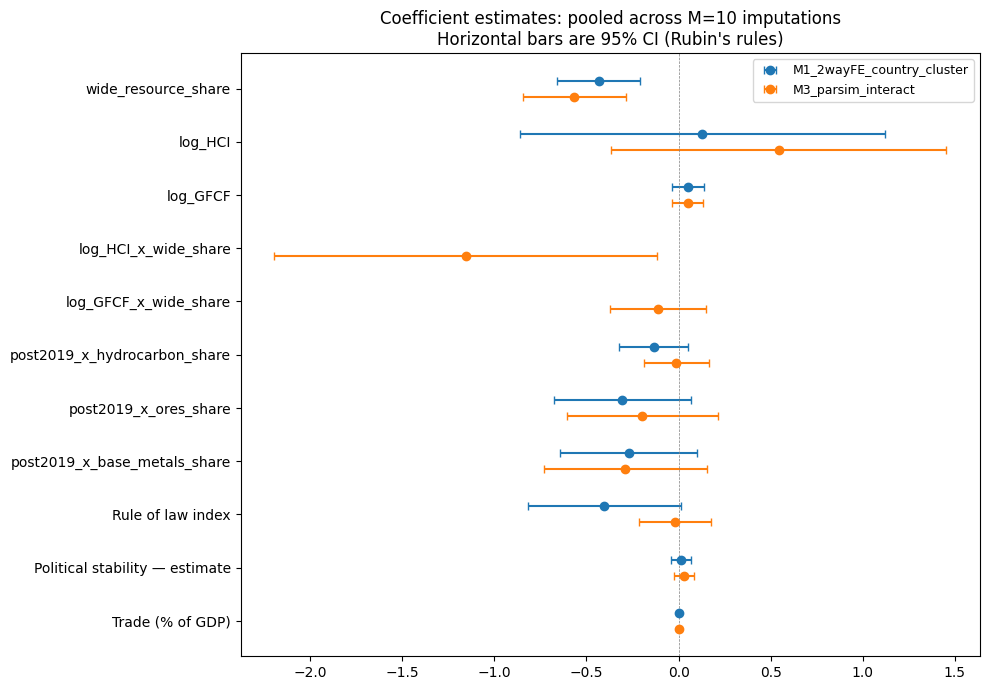

In [11]:
import matplotlib.pyplot as plt

KEY_VARS = [
    'wide_resource_share',
    'log_HCI',
    'log_GFCF',
    'log_HCI_x_wide_share',
    'log_GFCF_x_wide_share',
    'post2019_x_hydrocarbon_share',
    'post2019_x_ores_share',
    'post2019_x_base_metals_share',
    'Rule of law index',
    'Political stability — estimate',
    'Trade (% of GDP)',
    # log_GDPpc removed from KEY_VARS now that it is no longer in CONTROLS_FULL
]

# Take results from Models 1 and 3 (the FE specs of interest)
plot_data = all_results[
    (all_results['model'].isin(['M1_2wayFE_country_cluster', 'M3_parsim_interact']))
    & (all_results['variable'].isin(KEY_VARS))
].copy()

fig, ax = plt.subplots(figsize=(10, 7))
models = plot_data['model'].unique()
y_positions = np.arange(len(KEY_VARS))
offsets = np.linspace(-0.15, 0.15, len(models))

for i, model in enumerate(models):
    sub = plot_data[plot_data['model'] == model].set_index('variable')
    sub = sub.reindex(KEY_VARS)
    ax.errorbar(
        sub['beta'].values,
        y_positions + offsets[i],
        xerr=1.96 * sub['se'].values,
        fmt='o',
        capsize=3,
        label=model,
    )

ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_yticks(y_positions)
ax.set_yticklabels(KEY_VARS)
ax.invert_yaxis()
ax.legend(loc='best', fontsize=9)
ax.set_title('Coefficient estimates: pooled across M=10 imputations\nHorizontal bars are 95% CI (Rubin\'s rules)')
plt.tight_layout()

out_png = EXT / 'Graphics' / 'e5_coefficients.png'
out_png.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_png, dpi=150, bbox_inches='tight')
print(f'Saved: {out_png}')
plt.show()


## 12. Summary

In [12]:
print('=' * 70)
print('e5 — Regression results summary')
print('=' * 70)
for model_label, df in [
    ('Model 1 (Headline, 2wayFE, country-cluster)', m1),
    ('Model 2 (Robust SE, 2wayFE, two-way cluster)', m2),
    ('Model 3 (Parsimonious + interactions)', m3),
    ('Model 4 (Pooled OLS, v2 baseline)', m4),
    ('Model 5 (Observed-only)', m5),
]:
    if len(df) == 0:
        print(f'{model_label}: empty')
        continue
    n_obs = int(df['n_obs'].iloc[0])
    n_ctry = int(df['n_ctry'].iloc[0])
    r2 = df['r2_avg'].iloc[0]
    sig = (df['p'] < 0.05).sum()
    print(f'{model_label}')
    print(f'  N={n_obs:,}, countries={n_ctry}, R^2={r2:.3f}, sig vars (p<0.05): {sig}')
    print()

print('Files written:')
print(f'  intermediary/e5_results_long.csv   (long format)')
print(f'  intermediary/e5_results_wide.csv   (wide format for paper tables)')
print(f'  Graphics/e5_coefficients.png       (coefficient plot)')
print()
print('Next steps:')
print('  - Re-run e0 with PRODVAL_PATH fix to produce ProductionValue columns')
print('  - Re-run e1, e2 to propagate to Master_v2')
print('  - Add Model 6 (Production-Value spec) to e5')
print('  - e6: forecasting')
print('  - e3/e4: clustering and ML')


e5 — Regression results summary
Model 1 (Headline, 2wayFE, country-cluster)
  N=1,861, countries=73, R^2=0.159, sig vars (p<0.05): 5

Model 2 (Robust SE, 2wayFE, two-way cluster)
  N=1,861, countries=73, R^2=0.159, sig vars (p<0.05): 5

Model 3 (Parsimonious + interactions)
  N=2,468, countries=96, R^2=0.092, sig vars (p<0.05): 2

Model 4 (Pooled OLS, v2 baseline)
  N=1,861, countries=73, R^2=0.719, sig vars (p<0.05): 7

Model 5 (Observed-only)
  N=1,378, countries=73, R^2=0.189, sig vars (p<0.05): 7

Files written:
  intermediary/e5_results_long.csv   (long format)
  intermediary/e5_results_wide.csv   (wide format for paper tables)
  Graphics/e5_coefficients.png       (coefficient plot)

Next steps:
  - Re-run e0 with PRODVAL_PATH fix to produce ProductionValue columns
  - Re-run e1, e2 to propagate to Master_v2
  - Add Model 6 (Production-Value spec) to e5
  - e6: forecasting
  - e3/e4: clustering and ML
